In [2]:
print('Supreme')

Supreme


In [3]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer , StandardScaler ,  LabelEncoder    
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , f1_score


In [4]:
# Models 

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , ExtraTreesClassifier , BaggingClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier 


In [5]:
# loading of dataset 

df=pd.read_csv("predictive_maintenance.csv")
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,5402,M20261,M,302.6,312.3,1454,54.8,253,1
1,5401,L52580,L,302.7,312.4,1477,46.3,251,1
2,5400,H34813,H,302.8,312.4,1411,53.8,246,1
3,2865,H32278,H,300.6,309.4,1380,47.6,246,1
4,9672,L56851,L,299.0,310.2,1412,44.1,246,0
...,...,...,...,...,...,...,...,...,...
9995,1597,L48776,L,298.0,308.1,1877,24.3,0,0
9996,3028,L50207,L,300.5,309.5,1777,23.6,0,0
9997,4648,L51827,L,303.3,311.4,1958,21.5,0,0
9998,419,L47598,L,297.4,308.4,2151,17.7,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 771.6 KB


In [7]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
dtype: object

In [8]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# removal of variable which is not required for analysis
df = df.drop(['UDI', 'Product ID'], axis=1)
df


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,302.6,312.3,1454,54.8,253,1
1,L,302.7,312.4,1477,46.3,251,1
2,H,302.8,312.4,1411,53.8,246,1
3,H,300.6,309.4,1380,47.6,246,1
4,L,299.0,310.2,1412,44.1,246,0
...,...,...,...,...,...,...,...
9995,L,298.0,308.1,1877,24.3,0,0
9996,L,300.5,309.5,1777,23.6,0,0
9997,L,303.3,311.4,1958,21.5,0,0
9998,L,297.4,308.4,2151,17.7,0,0


In [12]:
df.columns = df.columns.str.strip().str.replace(" ", "").str.replace("[", "").str.replace("]", "").str.replace("/", "").str.lower()


In [13]:
df

,type,airtemperaturek,processtemperaturek,rotationalspeedrpm,torquenm,toolwearmin,target
0,M,302.6,312.3,1454,54.8,253,1
1,L,302.7,312.4,1477,46.3,251,1
2,H,302.8,312.4,1411,53.8,246,1
3,H,300.6,309.4,1380,47.6,246,1
4,L,299.0,310.2,1412,44.1,246,0
...,...,...,...,...,...,...,...
9995,L,298.0,308.1,1877,24.3,0,0
9996,L,300.5,309.5,1777,23.6,0,0
9997,L,303.3,311.4,1958,21.5,0,0
9998,L,297.4,308.4,2151,17.7,0,0


In [ ]:
# Label encoder for categorical varibale "type"


In [14]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("type mapping:", mapping)
df.head()

type mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


,type,airtemperaturek,processtemperaturek,rotationalspeedrpm,torquenm,toolwearmin,target
0,2,302.6,312.3,1454,54.8,253,1
1,1,302.7,312.4,1477,46.3,251,1
2,0,302.8,312.4,1411,53.8,246,1
3,0,300.6,309.4,1380,47.6,246,1
4,1,299.0,310.2,1412,44.1,246,0


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
type,10000.0,1.19940,0.600230,0.0,1.0,1.0,2.0,2.0
airtemperaturek,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
processtemperaturek,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
rotationalspeedrpm,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
torquenm,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
toolwearmin,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
target,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0


In [16]:
df.corr()

,type,airtemperaturek,processtemperaturek,rotationalspeedrpm,torquenm,toolwearmin,target
type,1.000000,0.017599,0.013444,-0.002693,0.004011,-0.003930,-0.005152
airtemperaturek,0.017599,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
processtemperaturek,0.013444,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
rotationalspeedrpm,-0.002693,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
torquenm,0.004011,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
toolwearmin,-0.003930,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
target,-0.005152,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


C:\Users\vikas\AppData\Local\Temp\ipykernel_13836\3508247067.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df, palette='pastel', order=order)
C:\Users\vikas\AppData\Local\Temp\ipykernel_13836\3508247067.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([mapping_inv.get(int(v), v) for v in order])


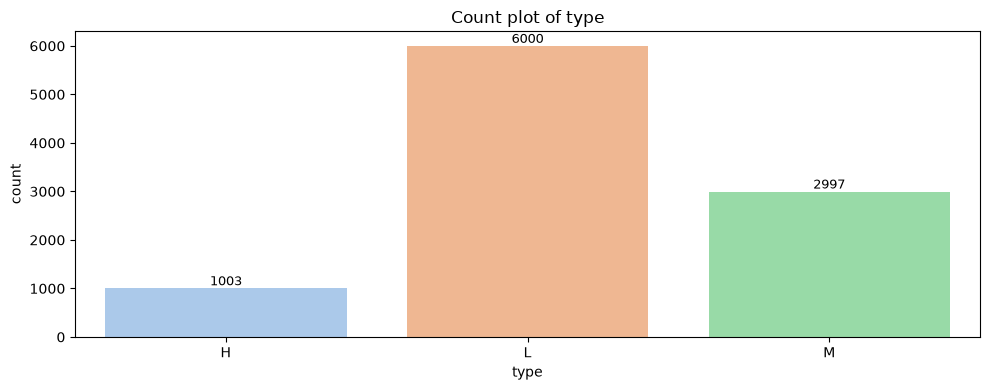

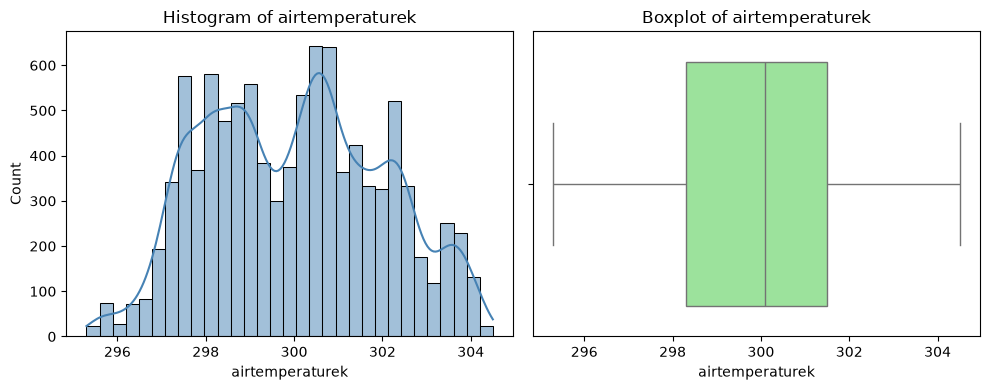

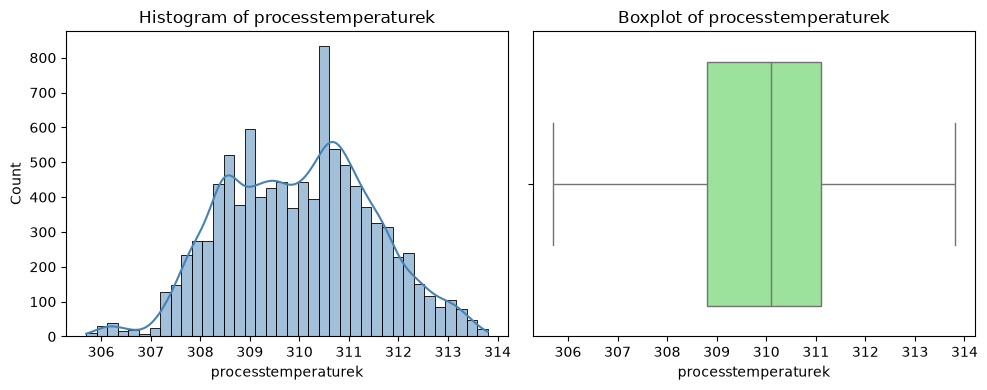

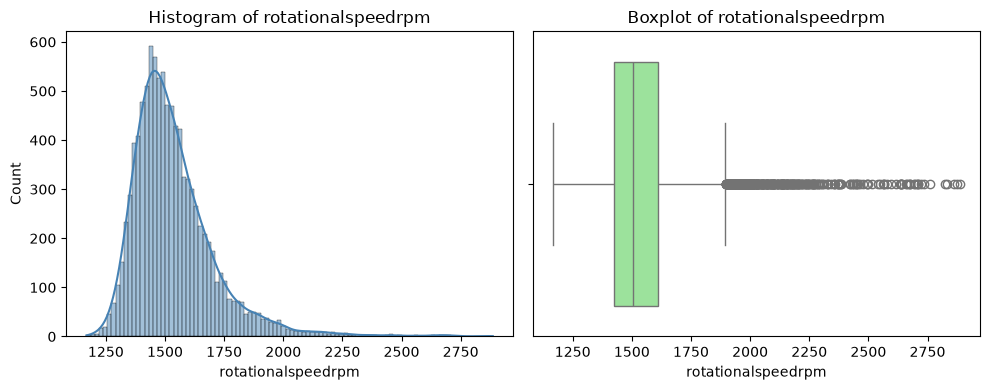

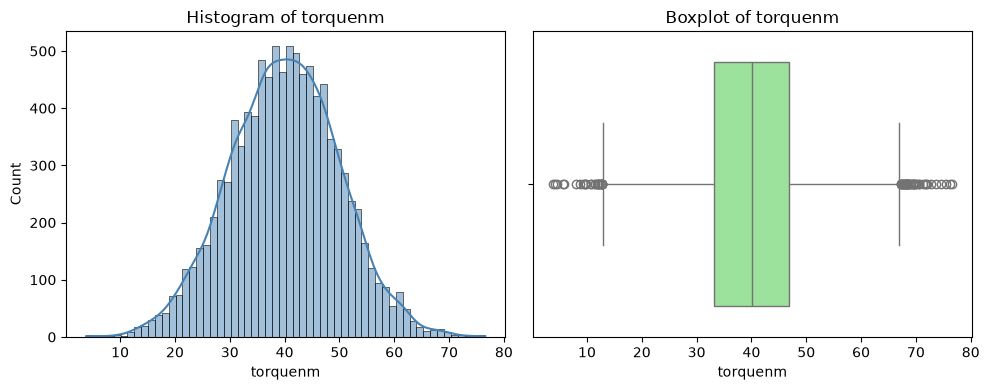

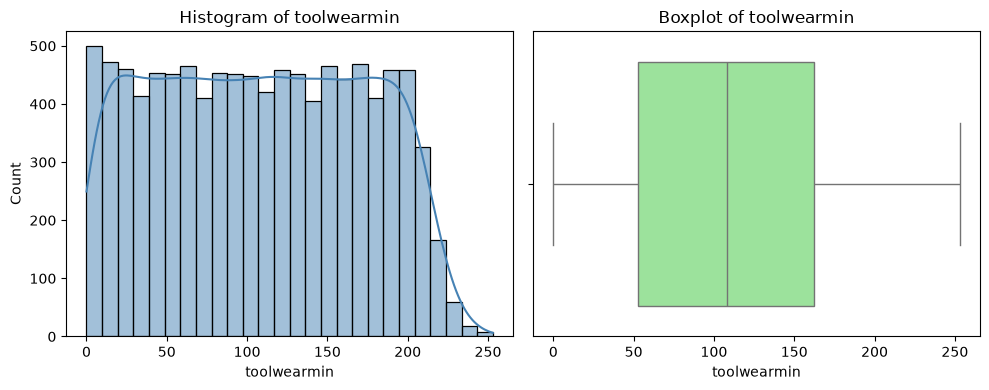

C:\Users\vikas\AppData\Local\Temp\ipykernel_13836\3508247067.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df, palette='pastel', order=order)


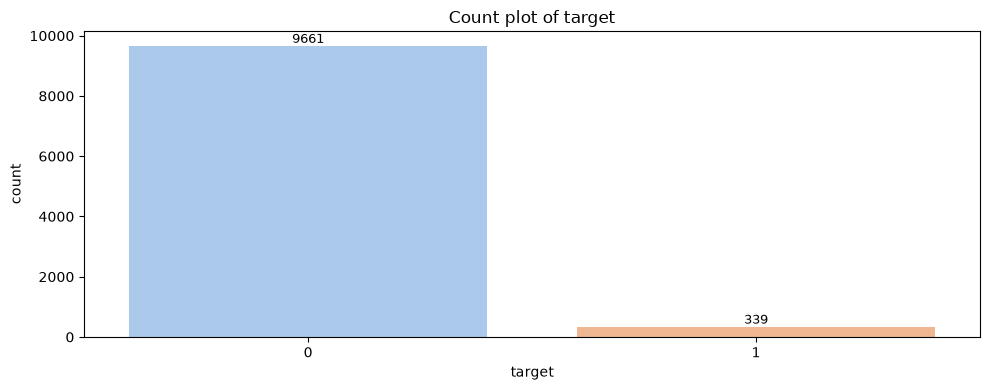

In [17]:
# Distribution visualization for all variables
# Numeric -> histogram + boxplot; Categorical (<=10 unique) -> countplot
mapping_inv = {v: k for k, v in mapping.items()} if 'mapping' in globals() else None

for col in df.columns:
    plt.figure(figsize=(10, 4))
    unique_vals = df[col].nunique()
    if unique_vals <= 10 and df[col].dtype != 'float':
        order = sorted(df[col].unique())
        ax = sns.countplot(x=col, data=df, palette='pastel', order=order)
        plt.title(f'Count plot of {col}')
        if col == 'type' and mapping_inv:
            ax.set_xticklabels([mapping_inv.get(int(v), v) for v in order])
        for p in ax.patches:
            ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9)
    else:
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True, color='steelblue')
        plt.title(f'Histogram of {col}')
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col], color='lightgreen')
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

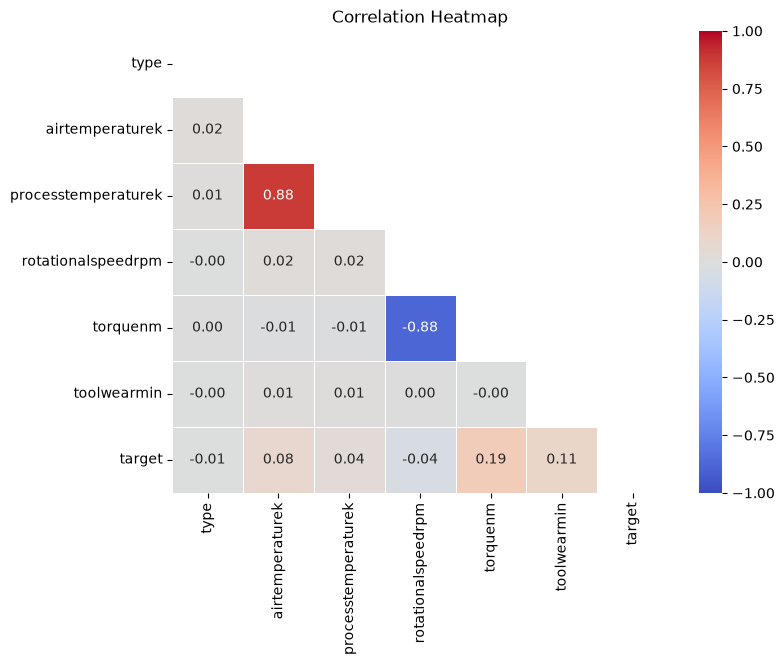

In [18]:
# Heatmap for Co-relation matrix
plt.figure(figsize=(8,6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmax=1, vmin=-1)
plt.title("Correlation Heatmap")
plt.show()

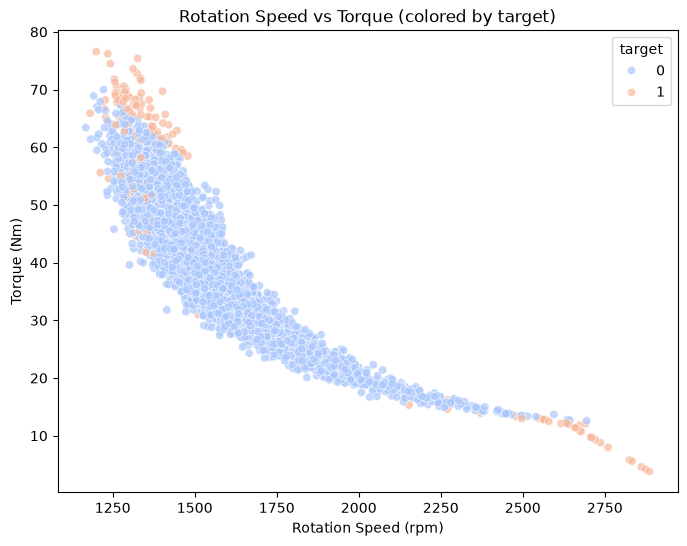

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='rotationalspeedrpm', y='torquenm', hue='target', palette='coolwarm', alpha=0.7)
plt.title('Rotation Speed vs Torque (colored by target)')
plt.xlabel('Rotation Speed (rpm)')
plt.ylabel('Torque (Nm)')
plt.legend(title='target')
plt.show()

In [20]:
numeric_cols = df.select_dtypes(include=['number']).columns.drop(['target', 'type'])
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness before transformation:")
print(skewness)

skewed_features = skewness[abs(skewness) > 0.5].index.tolist()

if skewed_features:
    pt = PowerTransformer()
    df[skewed_features] = pt.fit_transform(df[skewed_features])
    print("\nTransformed features:", skewed_features)
    print("\nSkewness after transformation:")
    print(df[skewed_features].skew().sort_values(ascending=False))
else:
    print("\nNo strongly skewed numeric features found (excluding target).")

Skewness before transformation:
rotationalspeedrpm     1.993171
airtemperaturek        0.114274
toolwearmin            0.027292
processtemperaturek    0.015027
torquenm              -0.009517
dtype: float64

Transformed features: ['rotationalspeedrpm']

Skewness after transformation:
rotationalspeedrpm    0.002328
dtype: float64


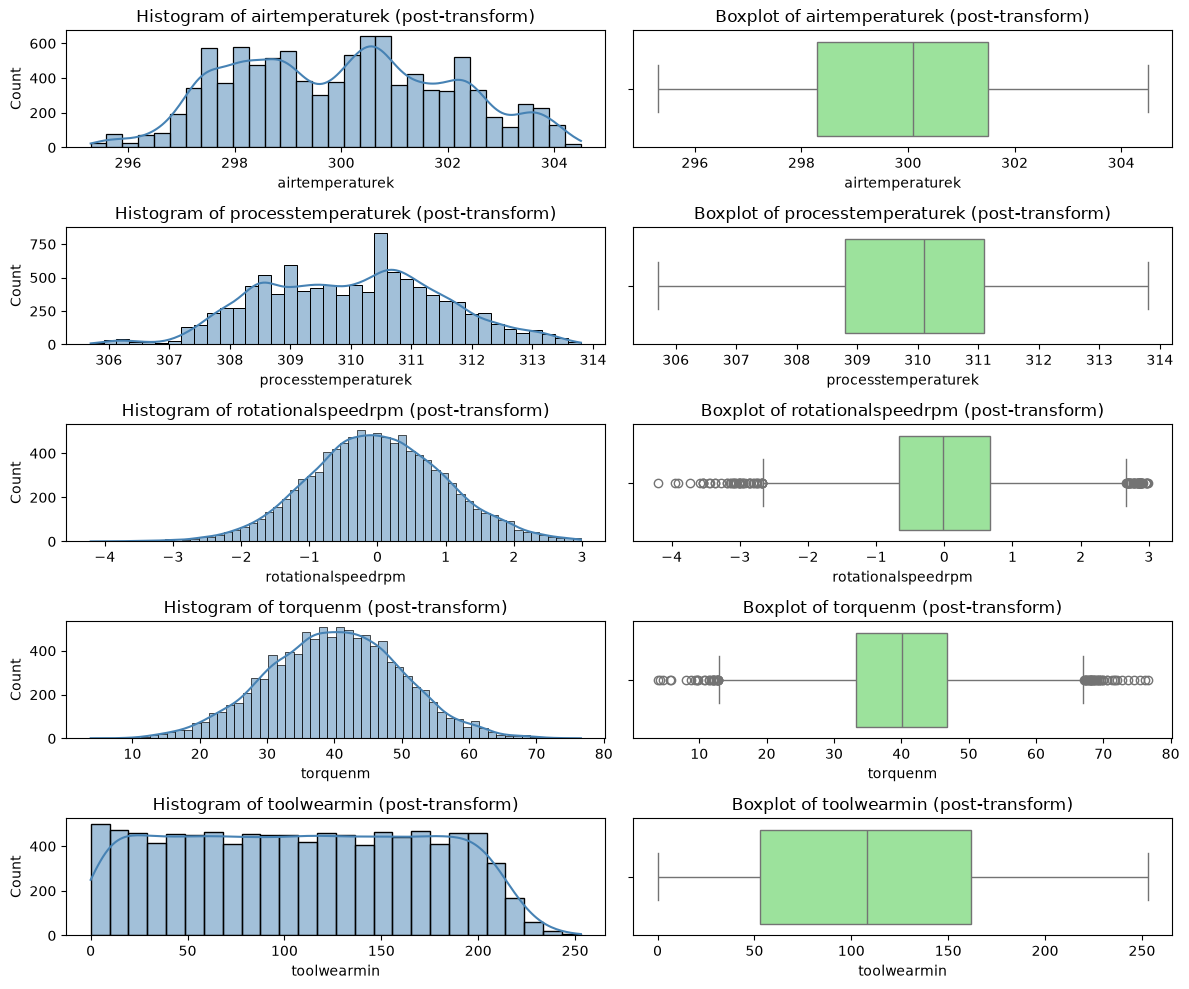

Skewness after transformation:
airtemperaturek        0.114274
toolwearmin            0.027292
processtemperaturek    0.015027
rotationalspeedrpm     0.002328
torquenm              -0.009517
dtype: float64


In [21]:
# Visualisation after skewness treatment
transformed_cols = numeric_cols.tolist()

plt.figure(figsize=(12, 10))
for i, col in enumerate(transformed_cols, 1):
    plt.subplot(len(transformed_cols), 2, 2*i - 1)
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f'Histogram of {col} (post-transform)')
    plt.subplot(len(transformed_cols), 2, 2*i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col} (post-transform)')

plt.tight_layout()
plt.show()

print("Skewness after transformation:")
print(df[transformed_cols].skew().sort_values(ascending=False))

In [22]:
# Outlier treatment using IQR capping on numeric predictors
numeric_cols = df.select_dtypes(include=['number']).columns.drop(['target', 'type'])

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

for col in numeric_cols:
    lower_count = (df[col] < lower_bound[col]).sum()
    upper_count = (df[col] > upper_bound[col]).sum()
    print(f"{col}: lower outliers={lower_count}, upper outliers={upper_count}")
    df[col] = df[col].clip(lower=lower_bound[col], upper=upper_bound[col])

print("\nAfter outlier treatment:")
print(df[numeric_cols].describe().T)

airtemperaturek: lower outliers=0, upper outliers=0
processtemperaturek: lower outliers=0, upper outliers=0
rotationalspeedrpm: lower outliers=46, upper outliers=44
torquenm: lower outliers=28, upper outliers=41
toolwearmin: lower outliers=0, upper outliers=0

After outlier treatment:
                       count        mean        std         min         25%  \
airtemperaturek      10000.0  300.004930   2.000259  295.300000  298.300000   
processtemperaturek  10000.0  310.005560   1.483734  305.700000  308.800000   
rotationalspeedrpm   10000.0    0.001401   0.991854   -2.660984   -0.664046   
torquenm             10000.0   39.983490   9.914623   12.800000   33.200000   
toolwearmin          10000.0  107.951000  63.654147    0.000000   53.000000   

                            50%         75%         max  
airtemperaturek      300.100000  301.500000  304.500000  
processtemperaturek  310.100000  311.100000  313.800000  
rotationalspeedrpm    -0.015204    0.667246    2.664184  
torquen

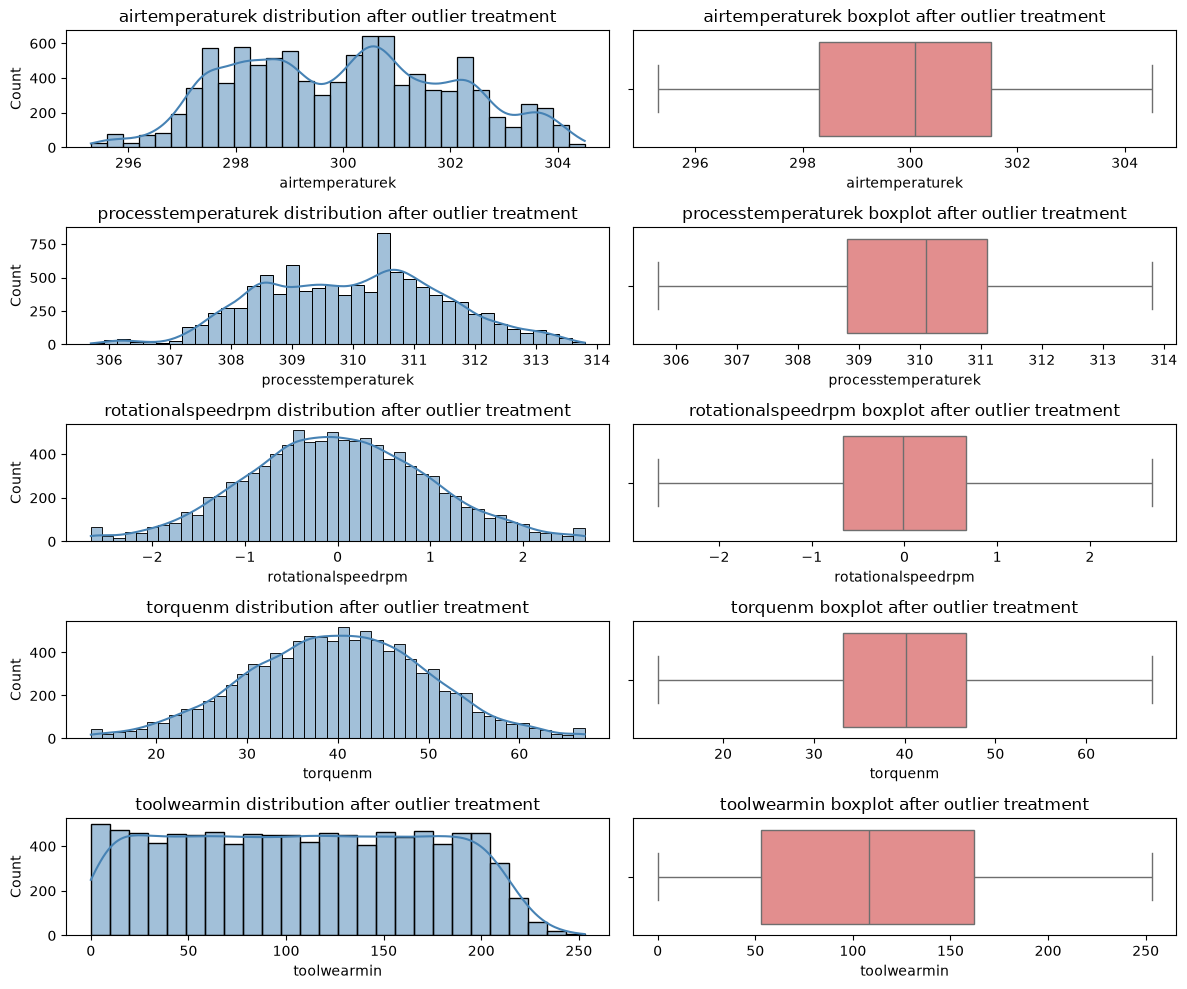

In [23]:
numeric_cols = df.select_dtypes(include=['number']).columns.drop(['target', 'type'])

plt.figure(figsize=(12, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 2, 2 * i - 1)
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f'{col} distribution after outlier treatment')

    plt.subplot(len(numeric_cols), 2, 2 * i)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'{col} boxplot after outlier treatment')

plt.tight_layout()
plt.show()

In [24]:
X = df.drop('target', axis=1)
y = df['target']

X.head(), y.head()

(   type  airtemperaturek  processtemperaturek  rotationalspeedrpm  torquenm  \
 0     2            302.6                312.3           -0.394921      54.8   
 1     1            302.7                312.4           -0.210155      46.3   
 2     0            302.8                312.4           -0.774926      53.8   
 3     0            300.6                309.4           -1.080290      47.6   
 4     1            299.0                310.2           -0.765532      44.1   
 
    toolwearmin  
 0          253  
 1          251  
 2          246  
 3          246  
 4          246  ,
 0    1
 1    1
 2    1
 3    1
 4    0
 Name: target, dtype: int64)

In [25]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,type,airtemperaturek,processtemperaturek,rotationalspeedrpm,torquenm,toolwearmin
0,1.333889,1.297432,1.546473,-0.399597,1.494485,2.278819
1,-0.332223,1.347428,1.613874,-0.213304,0.637122,2.247397
2,-1.998335,1.397424,1.613874,-0.782742,1.393618,2.168844
3,-1.998335,0.297511,-0.408153,-1.090629,0.768248,2.168844
4,-0.332223,-0.502425,0.131054,-0.773270,0.415217,2.168844


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((7500, 6), (2500, 6))

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Bagging": BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "SVC": SVC(kernel="rbf", random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, digits=4))
    results.append({"Model": name, "Accuracy": acc, "Weighted F1": f1})

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print("\nSummary of model performance:")
print(results_df)


Logistic Regression
Accuracy: 0.9688
Weighted F1: 0.9558
              precision    recall  f1-score   support

           0     0.9687    1.0000    0.9841      2415
           1     1.0000    0.0824    0.1522        85

    accuracy                         0.9688      2500
   macro avg     0.9844    0.5412    0.5681      2500
weighted avg     0.9698    0.9688    0.9558      2500


Decision Tree
Accuracy: 0.9828
Weighted F1: 0.9827
              precision    recall  f1-score   support

           0     0.9905    0.9917    0.9911      2415
           1     0.7561    0.7294    0.7425        85

    accuracy                         0.9828      2500
   macro avg     0.8733    0.8606    0.8668      2500
weighted avg     0.9825    0.9828    0.9827      2500


Random Forest
Accuracy: 0.9860
Weighted F1: 0.9845
              precision    recall  f1-score   support

           0     0.9865    0.9992    0.9928      2415
           1     0.9630    0.6118    0.7482        85

    accuracy        

c:\Users\vikas\DATA SCIENCE\Practice_Work\CAPSTONE_PROJECT_1\Predictive Maintenance\myenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:39:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                 Model  Train Accuracy  Test Accuracy  Accuracy Gap
0          Extra Trees        1.000000         0.9796      0.020400
1        Decision Tree        1.000000         0.9828      0.017200
2        Random Forest        1.000000         0.9860      0.014000
3              XGBoost        1.000000         0.9868      0.013200
4              Bagging        1.000000         0.9880      0.012000
5    Gradient Boosting        0.990933         0.9848      0.006133
6  K-Nearest Neighbors        0.978133         0.9736      0.004533
7                  SVC        0.973733         0.9708      0.002933
8          Gaussian NB        0.964800         0.9644      0.000400
9  Logistic Regression        0.968133         0.9688     -0.000667


C:\Users\vikas\AppData\Local\Temp\ipykernel_13836\4113829442.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overfit_df, x='Model', y='Accuracy Gap', palette='coolwarm')


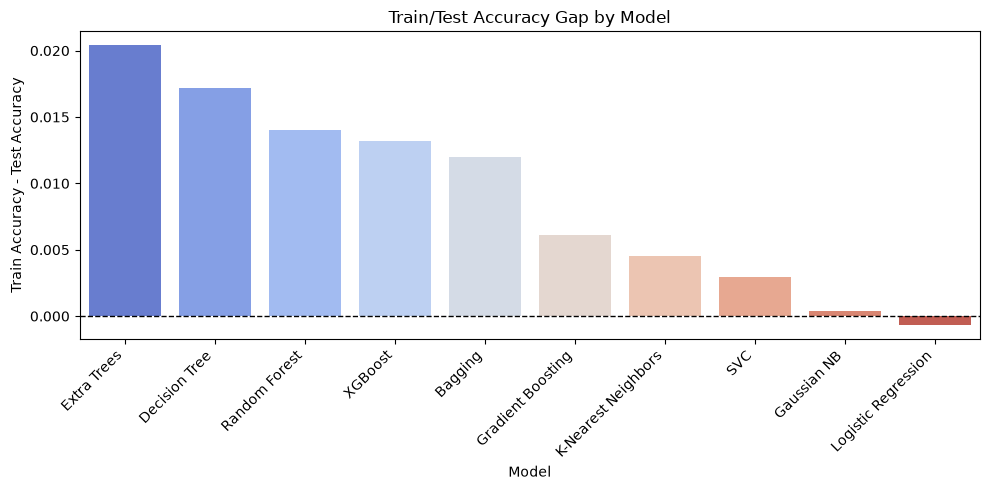

In [29]:
overfit_df = comparison_df.copy()
overfit_df['Accuracy Gap'] = overfit_df['Train Accuracy'] - overfit_df['Test Accuracy']
overfit_df = overfit_df.sort_values(by='Accuracy Gap', ascending=False).reset_index(drop=True)

print(overfit_df)


In [ ]:

plt.figure(figsize=(10, 5))
sns.barplot(data=overfit_df, x='Model', y='Accuracy Gap', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Train/Test Accuracy Gap by Model')
plt.ylabel('Train Accuracy - Test Accuracy')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()

In [31]:
best_by_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
best_by_f1 = results_df.loc[results_df['Weighted F1'].idxmax()]

best_overall = comparison_df.sort_values(
    by=['Test Accuracy', 'Overfitting Gap'],
    ascending=[False, True]
).iloc[0]

print("Best model by test accuracy:")
print(best_by_accuracy)
print("\nBest model by weighted F1:")
print(best_by_f1)
print("\nBest overall model considering high test accuracy and low overfitting gap:")
print(best_overall)

Best model by test accuracy:
Model           Bagging
Accuracy          0.988
Weighted F1    0.987312
Name: 0, dtype: object

Best model by weighted F1:
Model           Bagging
Accuracy          0.988
Weighted F1    0.987312
Name: 0, dtype: object

Best overall model considering high test accuracy and low overfitting gap:
Model              Bagging
Train Accuracy         1.0
Test Accuracy        0.988
Overfitting Gap      0.012
Name: 0, dtype: object


Full dataset target distribution:
target
0    9661
1     339
Name: count, dtype: int64

Training set target distribution before resampling:
target
0    7246
1     254
Name: count, dtype: int64


C:\Users\vikas\AppData\Local\Temp\ipykernel_13836\842841579.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="pastel")


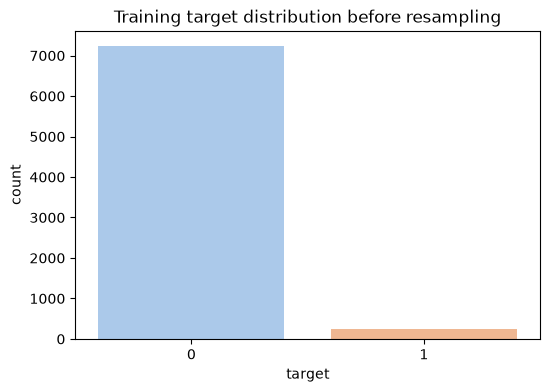


Training set target distribution after SMOTE:
Counter({0: 7246, 1: 7246})


C:\Users\vikas\AppData\Local\Temp\ipykernel_13836\842841579.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette="pastel")


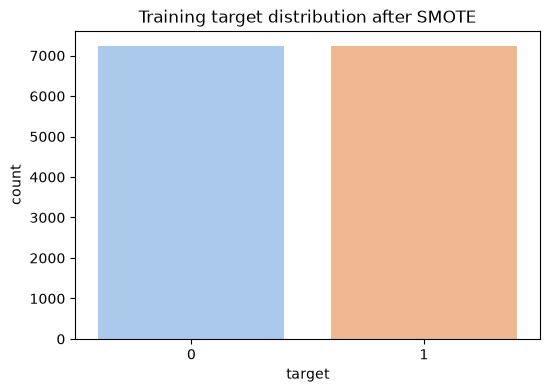

In [32]:
from collections import Counter
from imblearn.over_sampling import SMOTE

# Check class balance
print("Full dataset target distribution:")
print(y.value_counts())

print("\nTraining set target distribution before resampling:")
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette="pastel")
plt.title("Training target distribution before resampling")
plt.xlabel("target")
plt.ylabel("count")
plt.show()

# Treat class imbalance with SMOTE on the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nTraining set target distribution after SMOTE:")
print(Counter(y_train_res))

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_res, palette="pastel")
plt.title("Training target distribution after SMOTE")
plt.xlabel("target")
plt.ylabel("count")
plt.show()

In [33]:
# Train all applicable models on the SMOTE-resampled training data and evaluate on the test set
results_smote = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, digits=4))
    results_smote.append({"Model": name, "Accuracy": acc, "Weighted F1": f1})

results_smote_df = pd.DataFrame(results_smote).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print("\nSummary of model performance after SMOTE:")
print(results_smote_df)


Logistic Regression
Accuracy: 0.7592
Weighted F1: 0.8357
              precision    recall  f1-score   support

           0     0.9866    0.7611    0.8593      2415
           1     0.0942    0.7059    0.1662        85

    accuracy                         0.7592      2500
   macro avg     0.5404    0.7335    0.5127      2500
weighted avg     0.9562    0.7592    0.8357      2500


Decision Tree
Accuracy: 0.9644
Weighted F1: 0.9680
              precision    recall  f1-score   support

           0     0.9907    0.9723    0.9814      2415
           1     0.4846    0.7412    0.5860        85

    accuracy                         0.9644      2500
   macro avg     0.7377    0.8567    0.7837      2500
weighted avg     0.9735    0.9644    0.9680      2500


Random Forest
Accuracy: 0.9696
Weighted F1: 0.9723
              precision    recall  f1-score   support

           0     0.9920    0.9764    0.9841      2415
           1     0.5366    0.7765    0.6346        85

    accuracy        

c:\Users\vikas\DATA SCIENCE\Practice_Work\CAPSTONE_PROJECT_1\Predictive Maintenance\myenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:50:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [34]:
comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Train Accuracy,Test Accuracy,Overfitting Gap
0,Logistic Regression,0.968133,0.9688,-0.000667
1,Decision Tree,1.000000,0.9828,0.017200
2,Random Forest,1.000000,0.9860,0.014000
3,Gradient Boosting,0.990933,0.9848,0.006133
4,Extra Trees,1.000000,0.9796,0.020400
5,Bagging,1.000000,0.9880,0.012000
6,K-Nearest Neighbors,0.978133,0.9736,0.004533
7,Gaussian NB,0.964800,0.9644,0.000400
8,SVC,0.973733,0.9708,0.002933
9,XGBoost,1.000000,0.9868,0.013200


In [35]:
best_accuracy_smote = results_smote_df.loc[results_smote_df['Accuracy'].idxmax()]
best_f1_smote = results_smote_df.loc[results_smote_df['Weighted F1'].idxmax()]

print("Best model after SMOTE by accuracy:")
print(best_accuracy_smote)
print("\nBest model after SMOTE by weighted F1:")
print(best_f1_smote)

Best model after SMOTE by accuracy:
Model          XGBoost
Accuracy        0.9776
Weighted F1    0.97893
Name: 0, dtype: object

Best model after SMOTE by weighted F1:
Model          XGBoost
Accuracy        0.9776
Weighted F1    0.97893
Name: 0, dtype: object


In [36]:
top_n = 5

top_before = (
    results_df.sort_values("Accuracy", ascending=False)
    .head(top_n)
    .rename(columns={"Accuracy": "Accuracy_before", "Weighted F1": "Weighted F1_before"})
    .reset_index(drop=True)
)

top_after = (
    results_smote_df.sort_values("Accuracy", ascending=False)
    .head(top_n)
    .rename(columns={"Accuracy": "Accuracy_after", "Weighted F1": "Weighted F1_after"})
    .reset_index(drop=True)
)

comparison_table = pd.merge(top_before, top_after, on="Model", how="outer")
comparison_table

,Model,Accuracy_before,Weighted F1_before,Accuracy_after,Weighted F1_after
0,Bagging,0.9880,0.987312,0.9680,0.971362
1,Decision Tree,0.9828,0.982651,0.9644,0.967958
2,Extra Trees,NaN,NaN,0.9716,0.973347
3,Gradient Boosting,0.9848,0.983218,NaN,NaN
4,Random Forest,0.9860,0.984483,0.9696,0.972256
5,XGBoost,0.9868,0.985799,0.9776,0.978930


In [37]:
best_before_acc = results_df.loc[results_df['Accuracy'].idxmax()]
best_before_f1 = results_df.loc[results_df['Weighted F1'].idxmax()]

best_after_acc = results_smote_df.loc[results_smote_df['Accuracy'].idxmax()]
best_after_f1 = results_smote_df.loc[results_smote_df['Weighted F1'].idxmax()]

print("Best model before SMOTE by accuracy:")
print(best_before_acc)
print("\nBest model before SMOTE by weighted F1:")
print(best_before_f1)

print("\nBest model after SMOTE by accuracy:")
print(best_after_acc)
print("\nBest model after SMOTE by weighted F1:")
print(best_after_f1)

Best model before SMOTE by accuracy:
Model           Bagging
Accuracy          0.988
Weighted F1    0.987312
Name: 0, dtype: object

Best model before SMOTE by weighted F1:
Model           Bagging
Accuracy          0.988
Weighted F1    0.987312
Name: 0, dtype: object

Best model after SMOTE by accuracy:
Model          XGBoost
Accuracy        0.9776
Weighted F1    0.97893
Name: 0, dtype: object

Best model after SMOTE by weighted F1:
Model          XGBoost
Accuracy        0.9776
Weighted F1    0.97893
Name: 0, dtype: object


c:\Users\vikas\DATA SCIENCE\Practice_Work\CAPSTONE_PROJECT_1\Predictive Maintenance\myenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:55:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


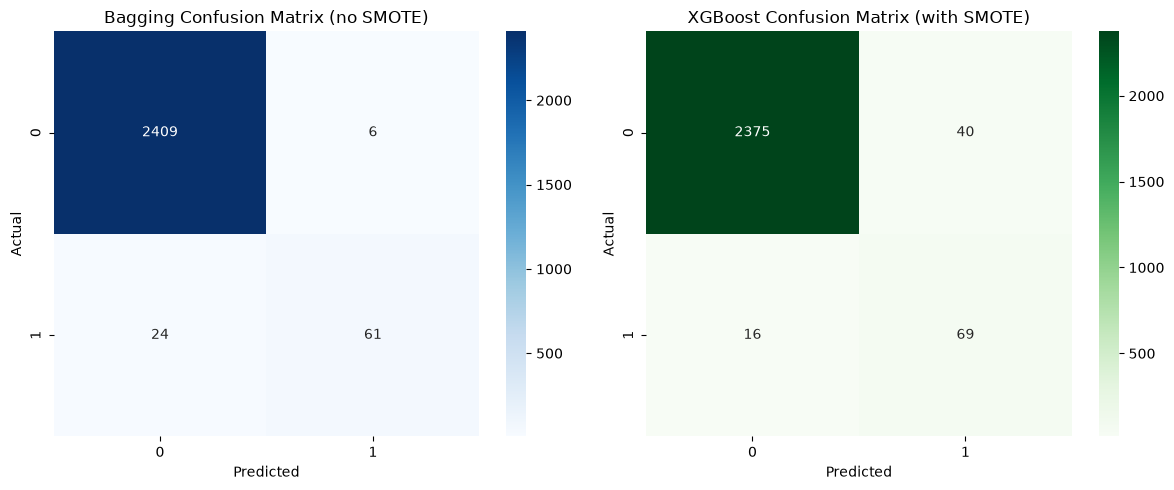

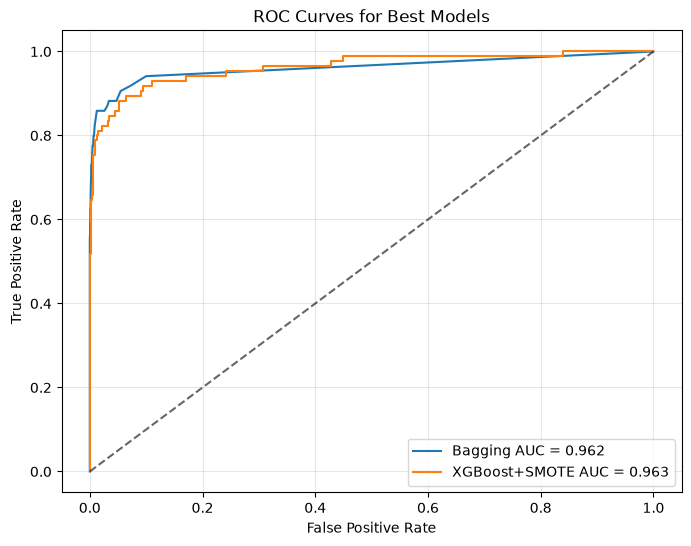

In [38]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

best_before_model = BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)
best_before_model.fit(X_train, y_train)
best_before_pred = best_before_model.predict(X_test)
best_before_proba = best_before_model.predict_proba(X_test)[:, 1]

best_after_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1)
best_after_model.fit(X_train_res, y_train_res)
best_after_pred = best_after_model.predict(X_test)
best_after_proba = best_after_model.predict_proba(X_test)[:, 1]

fpr_before, tpr_before, _ = roc_curve(y_test, best_before_proba)
fpr_after, tpr_after, _ = roc_curve(y_test, best_after_proba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, best_before_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Bagging Confusion Matrix (no SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, best_after_pred), annot=True, fmt="d", cmap="Greens")
plt.title("XGBoost Confusion Matrix (with SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr_before, tpr_before, label=f"Bagging AUC = {auc(fpr_before, tpr_before):.3f}")
plt.plot(fpr_after, tpr_after, label=f"XGBoost+SMOTE AUC = {auc(fpr_after, tpr_after):.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.title("ROC Curves for Best Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [39]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_before_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved best model to best_model.pkl and scaler to scaler.pkl")

Saved best model to best_model.pkl and scaler to scaler.pkl
